In [1]:
import os

import librosa
import librosa.display

import numpy as np

import soundfile as sf

import matplotlib.pyplot as plt

from scipy.io import wavfile

import tensorflow as tf

C:\Users\Tejeswar Srinivasan\AppData\Local\librosa\librosa\Cache\5703-47212-0000.ogg
Sample Rate: 16000
Duration: 14.84


### add noice

In [3]:
import librosa
import numpy as np
import soundfile as sf

speech, sr = librosa.load(
    librosa.ex("libri1"),
    sr=16000
)

noise = np.random.normal(
    0,
    0.05,
    len(speech)
)

noisy = speech + noise

sf.write(
    "noisy.wav",
    noisy,
    sr
)

In [6]:
path = r"./noisy.wav"
print(path)

audio, sr = librosa.load(
    path,
    sr=16000
)

print("Sample Rate:", sr)
print("Duration:", len(audio)/sr)

./noisy.wav
Sample Rate: 16000
Duration: 14.84


### Display Original Waveform

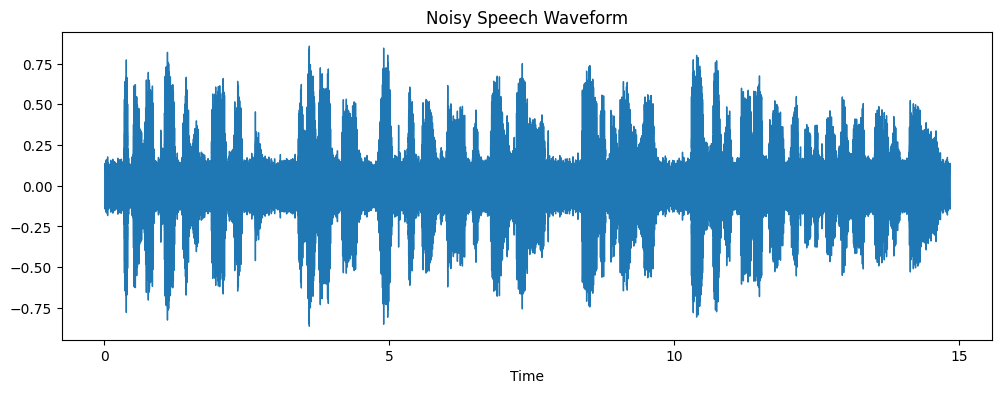

In [7]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Noisy Speech Waveform")

plt.show()

### Display Original Spectrogram

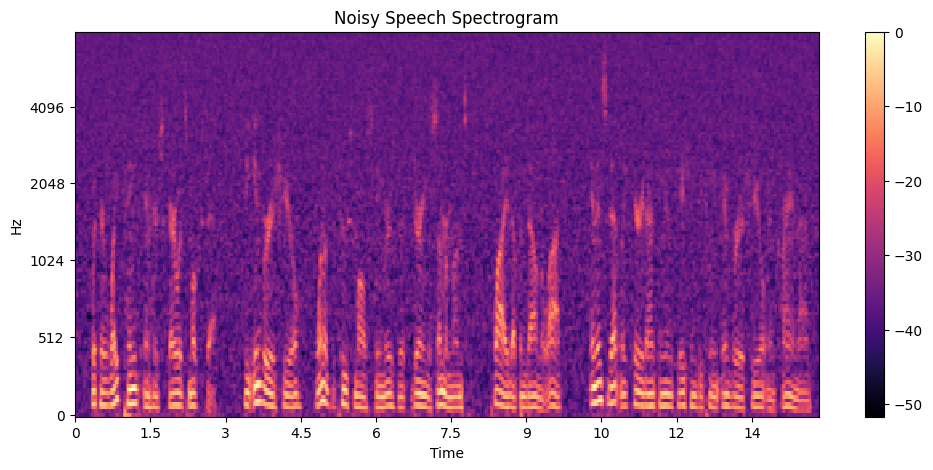

In [8]:
spec = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

spec_db = librosa.power_to_db(
    spec,
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    spec_db,
    x_axis="time",
    y_axis="mel",
    sr=sr
)

plt.colorbar()

plt.title("Noisy Speech Spectrogram")

plt.show()

### Load Pretrained DTLN Model

In [12]:
import tensorflow as tf

model = tf.saved_model.load(
    "model/"
)

### Prepare Audio

In [13]:
audio = audio.astype(np.float32)

block_len = 512
block_shift = 128

print(audio.shape)

(237440,)


### DTLN Inference

In [14]:
def frame_audio(signal,
                frame_length,
                frame_step):

    frames = []

    for i in range(
        0,
        len(signal)-frame_length,
        frame_step
    ):
        frames.append(
            signal[i:i+frame_length]
        )

    return np.array(frames)

In [15]:
frames = frame_audio(
    audio,
    block_len,
    block_shift
)

frames.shape

(1851, 512)

In [19]:
infer = model.signatures["serving_default"]

print(infer.structured_input_signature)
print(infer.structured_outputs)

((), {'input_1': TensorSpec(shape=(1, 512), dtype=tf.float32, name='input_1')})
{'conv1d_1': TensorSpec(shape=(1, 1, 512), dtype=tf.float32, name='conv1d_1')}


In [25]:
denoised_frames = []

for frame in frames:

    frame = frame.reshape(
        1,
        block_len
    )

    frame_tf = tf.convert_to_tensor(
    frame,
    dtype=tf.float32
    )

    prediction = infer(frame_tf)

    output_tensor = prediction["conv1d_1"]

    output_np = output_tensor.numpy()

    denoised_frames.append(
        np.squeeze(output_np)
    )
    
denoised_frames = np.array(
    denoised_frames
)

In [26]:
print(type(model))
print(model.signatures)

<class 'tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject'>
_SignatureMap({'serving_default': <ConcreteFunction (*, input_1: TensorSpec(shape=(1, 512), dtype=tf.float32, name='input_1')) -> Dict[['conv1d_1', TensorSpec(shape=(1, 1, 512), dtype=tf.float32, name='conv1d_1')]] at 0x1C16B6B6450>})


### Overlap Add Reconstruction

In [27]:
output_length = (
    len(denoised_frames)-1
) * block_shift + block_len

denoised_audio = np.zeros(
    output_length,
    dtype=np.float32
)

for idx, frame in enumerate(
    denoised_frames
):

    start = idx * block_shift

    denoised_audio[
        start:start+block_len
    ] += frame

### Save Denoised Audio

In [28]:
output_path = "denoised.wav"

sf.write(
    output_path,
    denoised_audio,
    sr
)

print(
    "Saved:",
    output_path
)

Saved: denoised.wav


### Denoised Waveform

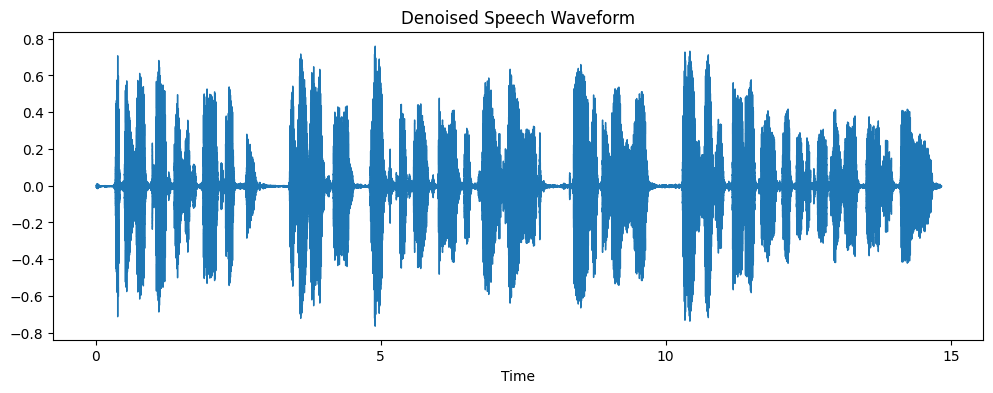

In [29]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    denoised_audio,
    sr=sr
)

plt.title(
    "Denoised Speech Waveform"
)

plt.show()

### Denoised Spectrogram

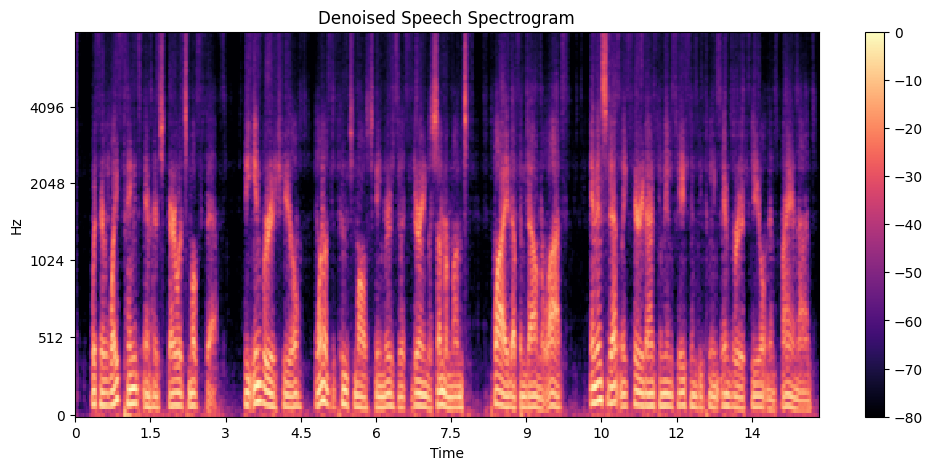

In [30]:
den_spec = librosa.feature.melspectrogram(
    y=denoised_audio,
    sr=sr
)

den_spec_db = librosa.power_to_db(
    den_spec,
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    den_spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title(
    "Denoised Speech Spectrogram"
)

plt.show()

### Waveform Comparison

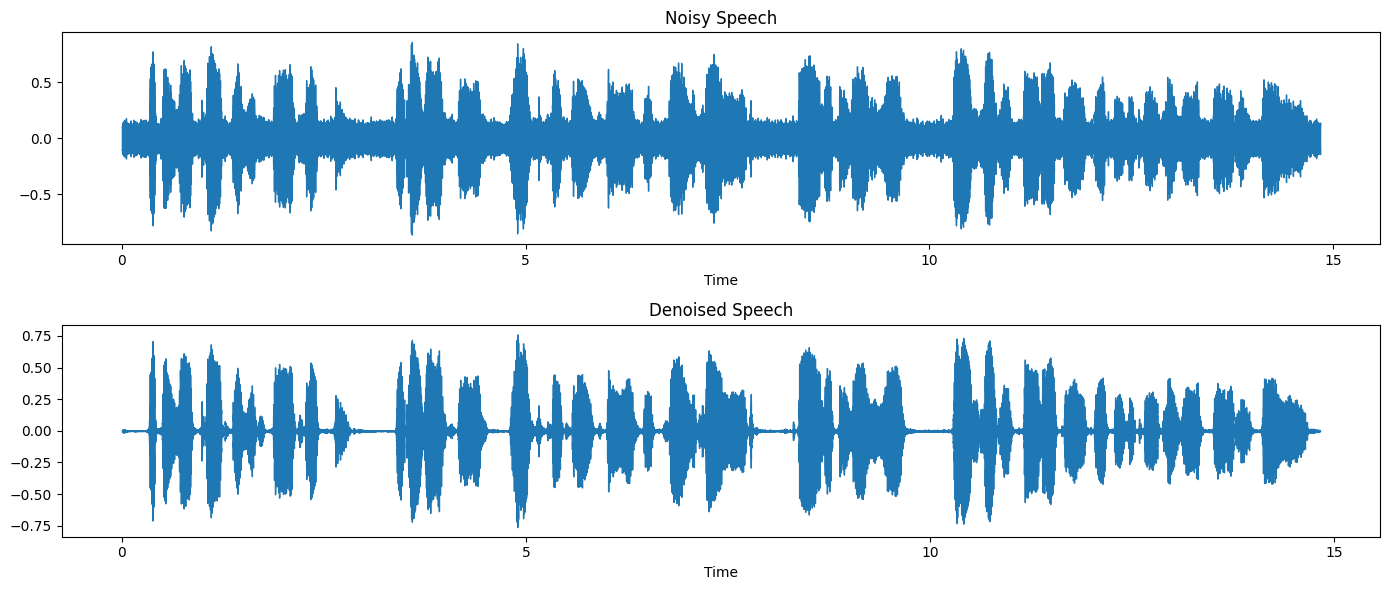

In [31]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(14,6)
)

librosa.display.waveshow(
    audio,
    sr=sr,
    ax=ax[0]
)

ax[0].set_title(
    "Noisy Speech"
)

librosa.display.waveshow(
    denoised_audio,
    sr=sr,
    ax=ax[1]
)

ax[1].set_title(
    "Denoised Speech"
)

plt.tight_layout()

plt.show()

### Spectrogram Comparison

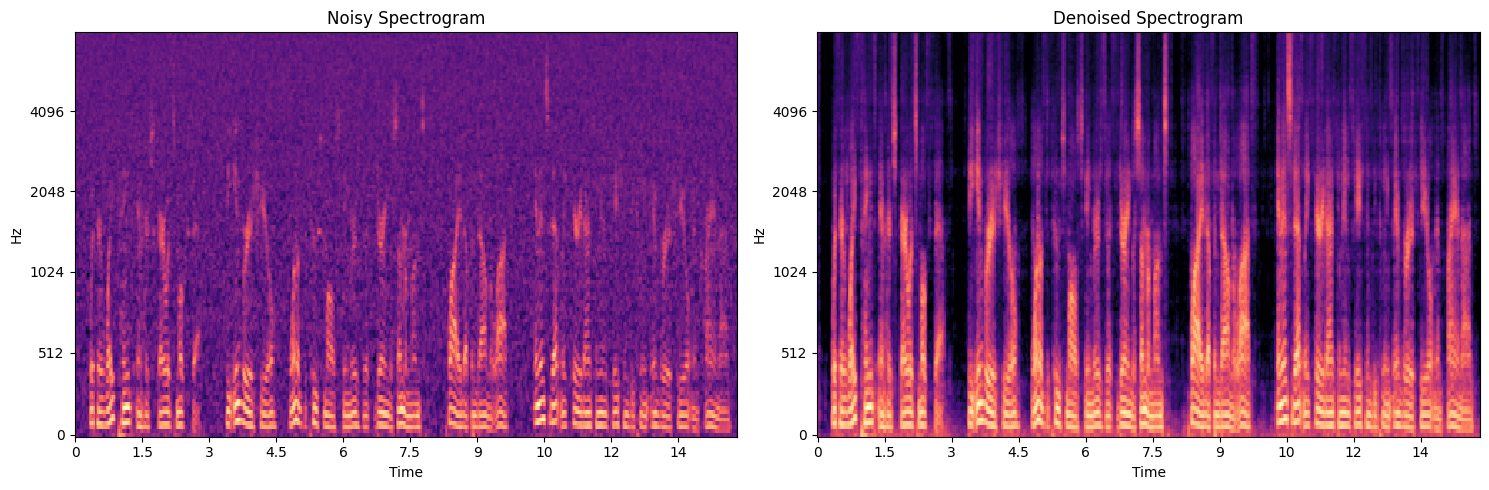

In [32]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(15,5)
)

librosa.display.specshow(
    spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
    ax=ax[0]
)

ax[0].set_title(
    "Noisy Spectrogram"
)

librosa.display.specshow(
    den_spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
    ax=ax[1]
)

ax[1].set_title(
    "Denoised Spectrogram"
)

plt.tight_layout()

plt.show()